In [136]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans 
import matplotlib.pyplot as plt

In [137]:
df = pd.read_csv("customer_segmentation_raw_300rows.csv")
df.head(6)

,CustomerID,Age,AnnualIncome,SpendingScore,OnlineVisits,PurchaseFrequency,CreditScore,LoanAmount,AccountBalance,Region,MembershipType
0,1,56,49855.0,9.0,21,0,414.0,330033,-18415,South,Silver
1,2,69,194088.0,71.0,20,29,508.0,154893,945043,South,Silver
2,3,46,27400.0,28.0,5,3,825.0,430783,239102,South,Silver
3,4,32,137858.0,78.0,0,21,820.0,115374,912854,West,Platinum
4,5,60,193714.0,95.0,4,1,536.0,24860,229922,East,Platinum
5,6,25,35151.0,52.0,40,9,580.0,152267,650601,West,Silver


In [138]:
df['OnlineVisits'] = pd.to_numeric(df['OnlineVisits'] , errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         300 non-null    int64  
 1   Age                300 non-null    int64  
 2   AnnualIncome       285 non-null    float64
 3   SpendingScore      285 non-null    float64
 4   OnlineVisits       290 non-null    float64
 5   PurchaseFrequency  300 non-null    int64  
 6   CreditScore        285 non-null    float64
 7   LoanAmount         300 non-null    int64  
 8   AccountBalance     300 non-null    int64  
 9   Region             300 non-null    object 
 10  MembershipType     300 non-null    object 
dtypes: float64(4), int64(5), object(2)
memory usage: 25.9+ KB


In [139]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,OnlineVisits,PurchaseFrequency,CreditScore,LoanAmount,AccountBalance
count,300.000000,300.000000,285.000000,285.000000,290.000000,300.000000,285.000000,3.000000e+02,300.000000
mean,150.500000,43.320000,118039.382456,49.961404,28.886207,14.720000,565.045614,2.688731e+05,491127.870000
std,86.746758,15.326686,84420.673254,28.728242,17.157246,8.788195,158.227199,1.790237e+05,313632.339969
min,1.000000,18.000000,22368.000000,1.000000,0.000000,0.000000,302.000000,6.154000e+03,-37885.000000
25%,75.750000,30.000000,63525.000000,25.000000,13.250000,7.000000,430.000000,1.524642e+05,200656.750000
50%,150.500000,43.500000,113468.000000,51.000000,29.000000,16.000000,567.000000,2.616100e+05,505672.000000
75%,225.250000,56.000000,155059.000000,75.000000,44.000000,22.000000,694.000000,3.740955e+05,744554.000000
max,300.000000,69.000000,848915.000000,99.000000,59.000000,29.000000,847.000000,1.776972e+06,998173.000000


In [140]:
df.isnull().sum()

CustomerID            0
Age                   0
AnnualIncome         15
SpendingScore        15
OnlineVisits         10
PurchaseFrequency     0
CreditScore          15
LoanAmount            0
AccountBalance        0
Region                0
MembershipType        0
dtype: int64

In [141]:
df['AnnualIncome'] = df['AnnualIncome'].fillna(df['AnnualIncome'].median())
df['SpendingScore'] = df['SpendingScore'].fillna(df['SpendingScore'].mean())
df['OnlineVisits'] = df['OnlineVisits'].fillna(df['OnlineVisits'].mean())
df = df.dropna(subset=['CreditScore'])
df.shape

(285, 11)

In [142]:
df.isnull().sum()

CustomerID           0
Age                  0
AnnualIncome         0
SpendingScore        0
OnlineVisits         0
PurchaseFrequency    0
CreditScore          0
LoanAmount           0
AccountBalance       0
Region               0
MembershipType       0
dtype: int64

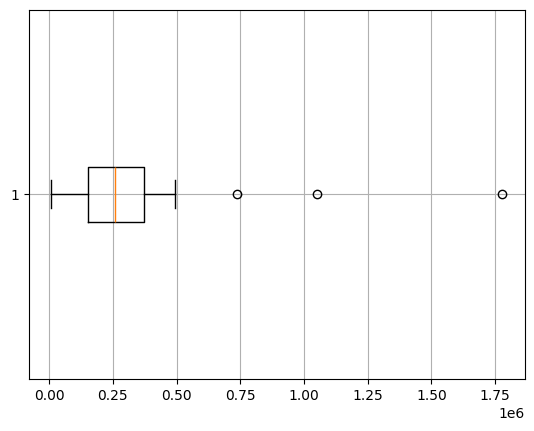

In [143]:
plt.boxplot(df['LoanAmount'],orientation='horizontal')
plt.grid(True)
plt.show()

In [144]:
def remove_outliers(df,col):
    q1 =df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    df[col] = np.where(df[col] >= upper , upper , df[col])
    df[col] = np.where(df[col] <= lower , lower , df[col])
    return df
remove_outliers(df,'AnnualIncome')
remove_outliers(df,'LoanAmount')

,CustomerID,Age,AnnualIncome,SpendingScore,OnlineVisits,PurchaseFrequency,CreditScore,LoanAmount,AccountBalance,Region,MembershipType
0,1,56,49855.0,9.0,21.0,0,414.0,330033.0,-18415,South,Silver
1,2,69,194088.0,71.0,20.0,29,508.0,154893.0,945043,South,Silver
2,3,46,27400.0,28.0,5.0,3,825.0,430783.0,239102,South,Silver
3,4,32,137858.0,78.0,0.0,21,820.0,115374.0,912854,West,Platinum
4,5,60,193714.0,95.0,4.0,1,536.0,24860.0,229922,East,Platinum
...,...,...,...,...,...,...,...,...,...,...,...
295,296,18,198352.0,21.0,56.0,23,700.0,266847.0,143783,North,Silver
296,297,65,99459.0,5.0,32.0,26,321.0,196200.0,-31248,West,Silver
297,298,29,167851.0,82.0,36.0,13,773.0,72099.0,965416,West,Gold
298,299,22,175538.0,92.0,26.0,22,419.0,419065.0,687565,North,Gold


In [145]:
# pd.unique(df['MembershipType'])
pd.unique(df['Region'])

array(['South', 'West', 'East', 'North'], dtype=object)

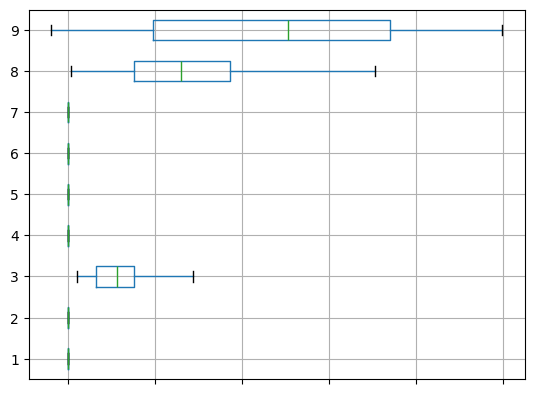

In [146]:
df.boxplot(orientation='horizontal')
plt.show()

In [147]:
le = LabelEncoder()
df['Region'] = le.fit_transform(df['Region'])
df['MembershipType'] = le.fit_transform(df['MembershipType'])
df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,OnlineVisits,PurchaseFrequency,CreditScore,LoanAmount,AccountBalance,Region,MembershipType
0,1,56,49855.0,9.0,21.0,0,414.0,330033.0,-18415,2,2
1,2,69,194088.0,71.0,20.0,29,508.0,154893.0,945043,2,2
2,3,46,27400.0,28.0,5.0,3,825.0,430783.0,239102,2,2
3,4,32,137858.0,78.0,0.0,21,820.0,115374.0,912854,3,1
4,5,60,193714.0,95.0,4.0,1,536.0,24860.0,229922,0,1


In [148]:
scaler = StandardScaler()
df['Age'] = scaler.fit_transform(df[['Age']])
df['AnnualIncome'] = scaler.fit_transform(df[['AnnualIncome']])
df['SpendingScore'] = scaler.fit_transform(df[['SpendingScore']])
df['OnlineVisits'] = scaler.fit_transform(df[['OnlineVisits']])
df['PurchaseFrequency'] = scaler.fit_transform(df[['PurchaseFrequency']])
df['CreditScore'] = scaler.fit_transform(df[['CreditScore']])
df['LoanAmount'] = scaler.fit_transform(df[['LoanAmount']])
df['AccountBalance'] = scaler.fit_transform(df[['AccountBalance']])
df.drop('CustomerID',axis=1,inplace=True)
df.head()


,Age,AnnualIncome,SpendingScore,OnlineVisits,PurchaseFrequency,CreditScore,LoanAmount,AccountBalance,Region,MembershipType
0,0.845839,-1.117024,-1.446322,-0.450818,-1.657532,-0.956291,0.498546,-1.607467,2,2
1,1.704188,1.426009,0.754454,-0.509976,1.622215,-0.361164,-0.757186,1.452048,2,2
2,0.185570,-1.512938,-0.771891,-1.397347,-1.318248,1.645808,1.220911,-0.789707,2,2
3,-0.738806,0.434594,1.002929,-1.693137,0.717457,1.614153,-1.040532,1.349830,3,1
4,1.109946,1.419415,1.606368,-1.456505,-1.544438,-0.183892,-1.689507,-0.818859,0,1


In [149]:
inertia=[]
for k in range(1,11):
    model=KMeans(n_clusters=k , random_state=42)
    model.fit(df)
    inertia.append(model.inertia_)

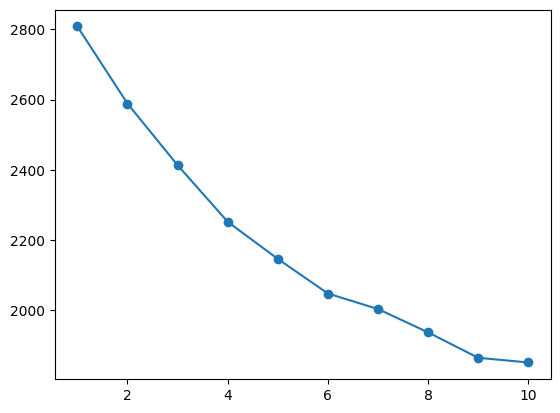

In [150]:
plt.plot(range(1,11),inertia,marker='o')
plt.show()

In [151]:
pca = PCA(n_components=2)
df = pca.fit_transform(df)
df = pd.DataFrame(df , columns=['PCA1','PCA2'])
variance = pca.explained_variance_ratio_
print(np.round(variance*100,2))


[13.23 12.32]


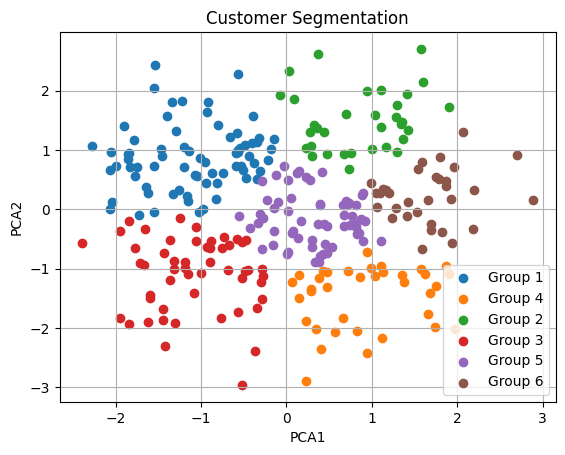

In [152]:
model = KMeans(n_clusters=6 , random_state=42 , n_init=50)
df['Group'] = model.fit_predict(df)
for group in df['Group'].unique():
    group_data = df[df['Group'] == group]
    plt.scatter(group_data['PCA1'],group_data['PCA2'],label=f"Group {group+1}")
plt.legend()
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Customer Segmentation")
plt.grid(True)
plt.show()